In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('..\..\Data\df_with_2regimes.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3518 entries, 0 to 3517
Data columns (total 37 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        3518 non-null   object 
 1   log_return                                  3518 non-null   float64
 2   realized_variance                           3518 non-null   float64
 3   realized_volatility                         3518 non-null   float64
 4   gtrend_pct_change                           3518 non-null   float64
 5   blockchain_diff_log_n_transactions          3518 non-null   float64
 6   blockchain_diff_log_transaction_fee_usd     3518 non-null   float64
 7   blockchain_diff_log_n_unique_addresses      3518 non-null   float64
 8   blockchain_diff_log_transaction_volume_usd  3518 non-null   float64
 9   log_volume                                  3518 non-null   float64
 10  target      

In [5]:
# lag 1,2 andd 3 of realized volatility
df['rv_lag1'] = df['realized_volatility'].shift(1)
df['rv_lag2'] = df['realized_volatility'].shift(2)
df['rv_lag3'] = df['realized_volatility'].shift(3)

# rolling mean of realized volatility over the past 7 & 30 days
df['rv_rolling_mean_7'] = df['realized_volatility'].rolling(window=7).mean() 
df['rv_rolling_mean_30'] = df['realized_volatility'].rolling(window=30).mean() 

df['target'] = df['realized_volatility'].shift(-1)

# drop rows with NaN values (due to lag and rolling mean)
df = df.dropna().reset_index(drop=True)
df.head(30)
df.info()
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3488 entries, 0 to 3487
Data columns (total 42 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        3488 non-null   object 
 1   log_return                                  3488 non-null   float64
 2   realized_variance                           3488 non-null   float64
 3   realized_volatility                         3488 non-null   float64
 4   gtrend_pct_change                           3488 non-null   float64
 5   blockchain_diff_log_n_transactions          3488 non-null   float64
 6   blockchain_diff_log_transaction_fee_usd     3488 non-null   float64
 7   blockchain_diff_log_n_unique_addresses      3488 non-null   float64
 8   blockchain_diff_log_transaction_volume_usd  3488 non-null   float64
 9   log_volume                                  3488 non-null   float64
 10  target      

In [6]:
# drop columns for regimes 
df = df.drop(columns=['p_sigma', 'p_r', 'p_d', 'regime', 'regime_id', 'date', 'realized_variance'], errors='ignore').copy()

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3488 entries, 0 to 3487
Data columns (total 35 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   log_return                                  3488 non-null   float64
 1   realized_volatility                         3488 non-null   float64
 2   gtrend_pct_change                           3488 non-null   float64
 3   blockchain_diff_log_n_transactions          3488 non-null   float64
 4   blockchain_diff_log_transaction_fee_usd     3488 non-null   float64
 5   blockchain_diff_log_n_unique_addresses      3488 non-null   float64
 6   blockchain_diff_log_transaction_volume_usd  3488 non-null   float64
 7   log_volume                                  3488 non-null   float64
 8   target                                      3488 non-null   float64
 9   gold_close_ret                              3488 non-null   float64
 10  silver_close

In [7]:
all_features = [col for col in df.columns if col != 'target']

print(f"Total features being used: {len(all_features)}") 

Total features being used: 34


In [8]:
# split data into train, evaluation and out of sample test sets 60/25/15
n= len(df)

train_size = int(n * 0.6)
eval_size = int(n * 0.25)

train_start_idx = 0
train_end_idx = train_size

eval_start_idx = train_size 
eval_end_idx = eval_start_idx + eval_size

test_start_idx = eval_end_idx
text_end_idx = n

train_df = df.iloc[train_start_idx:train_end_idx].copy()
eval_df = df.iloc[eval_start_idx:eval_end_idx].copy()
test_df = df.iloc[test_start_idx:text_end_idx].copy()

print(f"Train set: {len(train_df)} rows")
print(f"Evaluation set: {len(eval_df)} rows")
print(f"Test set: {len(test_df)} rows")

Train set: 2092 rows
Evaluation set: 872 rows
Test set: 524 rows


In [9]:
# --- HYPERPARAMETER TUNING ---
# Fit once on the combined Train/Eval data to get best C and epsilon
X_tune = df.iloc[:test_start_idx][all_features]
y_tune = df.iloc[:test_start_idx]['target']

scaler_tune = StandardScaler()
X_tune_scaled = scaler_tune.fit_transform(X_tune)

In [10]:
# 1. Define the parameter grid
# We test a wide range of C and very small epsilons for variance
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'epsilon': [1e-4, 1e-3, 1e-2]
}

# 2. Setup the model
svr_base = LinearSVR(dual=True, random_state=42, max_iter=20000, tol=1e-3)

# 3. Setup Grid Search
# Note: We use the eval_df to find these best settings
grid_search = GridSearchCV(
    estimator=svr_base,
    param_grid=param_grid,
    scoring='neg_mean_squared_error', # MSE is standard for tuning
    cv=5 # 5-fold cross-validation on the training/eval data
)

# 4. Fit on the Training + Eval data combined
# This gives the model enough data to find stable parameters
grid_search.fit(X_tune_scaled, y_tune)

# 5. Get the Best Parameters
best_c = grid_search.best_params_['C']
best_eps = grid_search.best_params_['epsilon']

print(f"Best C: {best_c}")
print(f"Best Epsilon: {best_eps}")

C:\Users\tklia\OneDrive\Documents\DSE4211\Project\SVR-L Code\vol_project\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\tklia\OneDrive\Documents\DSE4211\Project\SVR-L Code\vol_project\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\tklia\OneDrive\Documents\DSE4211\Project\SVR-L Code\vol_project\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\tklia\OneDrive\Documents\DSE4211\Project\SVR-L Code\vol_project\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\tklia\OneDrive\Documents\DSE4211\Project\SVR-L Code\vol_project\lib\site-packages\sklearn\svm\_base.py:1250: Co

Best C: 0.1
Best Epsilon: 0.01


In [15]:
results = []
window_size = 365 

# We start at test_start_idx and go to the end of the dataframe
for t in range(test_start_idx, len(df)):
    
    # 1. Define the sliding window (the 365 days leading up to today)
    train_window = df.iloc[t - window_size : t]
    
    # 2. Today's features (to predict the 'target' which is tomorrow's variance)
    test_row = df.iloc[[t]]
    
    # Separate X and y
    X_train_roll = train_window[all_features]
    y_train_roll = train_window['target']
    X_test_now = test_row[all_features]
    y_actual = test_row['target'].values[0]
    
    # 3. Scaling (MUST fit on the rolling training window only to avoid leakage)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_roll)
    X_test_scaled = scaler.transform(X_test_now)
    
    # 4. Initialize and train with your TUNED parameters
    # dual=True is used here to match the GridSearchCV logic
    model = LinearSVR(
        C=best_c, 
        epsilon=best_eps, 
        dual=True, 
        random_state=42, 
        max_iter=20000
    )
    model.fit(X_train_scaled, y_train_roll)
    
    # 5. Predict
    y_pred_val = model.predict(X_test_scaled)[0]
    
    #Instead of 1e-10, use the moving average of the window
    y_pred_val = max(y_pred_val, 1e-10)
    
    # Store results for the final report
    results.append({
        "date": test_row['date'].values[0] if 'date' in df.columns else t,
        "actual": y_actual,
        "predicted": y_pred_val
    })

C:\Users\tklia\OneDrive\Documents\DSE4211\Project\SVR-L Code\vol_project\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\tklia\OneDrive\Documents\DSE4211\Project\SVR-L Code\vol_project\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\tklia\OneDrive\Documents\DSE4211\Project\SVR-L Code\vol_project\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\tklia\OneDrive\Documents\DSE4211\Project\SVR-L Code\vol_project\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\tklia\OneDrive\Documents\DSE4211\Project\SVR-L Code\vol_project\lib\site-packages\sklearn\svm\_base.py:1250: Co

In [16]:
results_df = pd.DataFrame(results)

def calculate_qlike(y_true, y_pred):
    # Ensure y_pred is strictly positive to avoid log(0) or log(-ve)
    y_pred = np.maximum(y_pred, 1e-10) 
    return np.mean(np.log(y_pred) + (y_true / y_pred))

rmse_roll = np.sqrt(mean_squared_error(results_df['actual'], results_df['predicted']))
mae_roll = mean_absolute_error(results_df['actual'], results_df['predicted'])
qlike_roll = calculate_qlike(results_df['actual'], results_df['predicted'])

print("\n" + "="*40)
print("SVR-L PERFORMANCE")
print("="*40)
print(f"RMSE:  {rmse_roll:.10f}")
print(f"MAE:   {mae_roll:.10f}")
print(f"QLIKE: {qlike_roll:.10f}")
print(f"Number of forecasts: {len(results_df['predicted'])}")


SVR-L PERFORMANCE
RMSE:  0.0099285108
MAE:   0.0075590548
QLIKE: -2.8767442763
Number of forecasts: 524


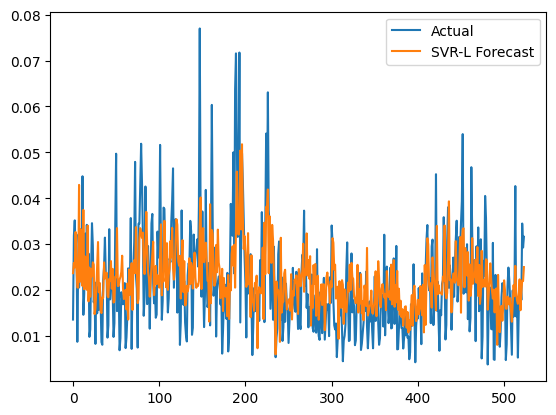

In [13]:
# Plotting
plt.plot(results_df['actual'], label="Actual")
plt.plot(results_df['predicted'], label="SVR-L Forecast")
plt.legend()
plt.show()